In [150]:
import os
import time

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [151]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [152]:
df.shape

(569, 31)

In [153]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

CLASSIFICATION

Classification in machine learning involves sorting data into categories based on their features or characteristics. The type of classification problem depends on how many classes exist and how the categories are structured.

In this project, five classification algorithms are implemented:

•	Logistic Regression 

•	Decision Tree 

•	Random Forest 

•	Support Vector Machine 

•	K-Nearest Neighbours 

Each model is trained and evaluated to determine its performance in predicting breast cancer diagnosis


In [154]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9824561403508771


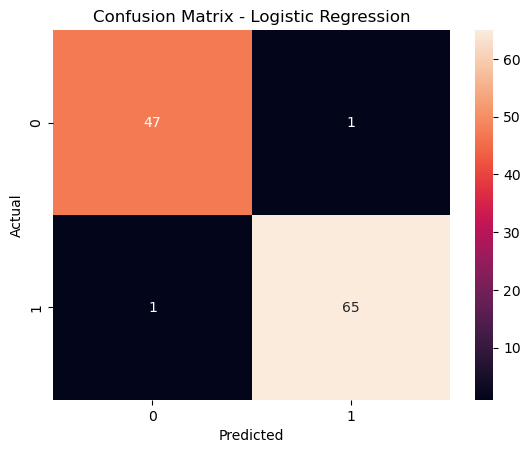

In [155]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig(f"outputs/plot_{int(time.time())}.png", dpi=300, bbox_inches='tight')
plt.show()

In [156]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Initialize model
dt_model = DecisionTreeClassifier()

# Train model
dt_model.fit(X_train, y_train)

# Predict
y_pred_dt = dt_model.predict(X_test)

# Accuracy
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9298245614035088


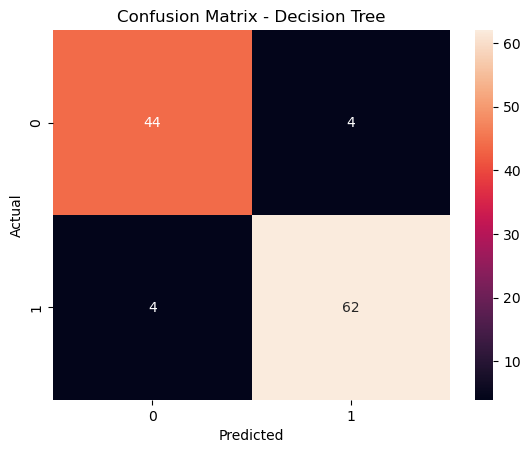

In [157]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_dt = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm_dt, annot=True, fmt='d')
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig(f"outputs/plot_{int(time.time())}.png", dpi=300, bbox_inches='tight')
plt.show()

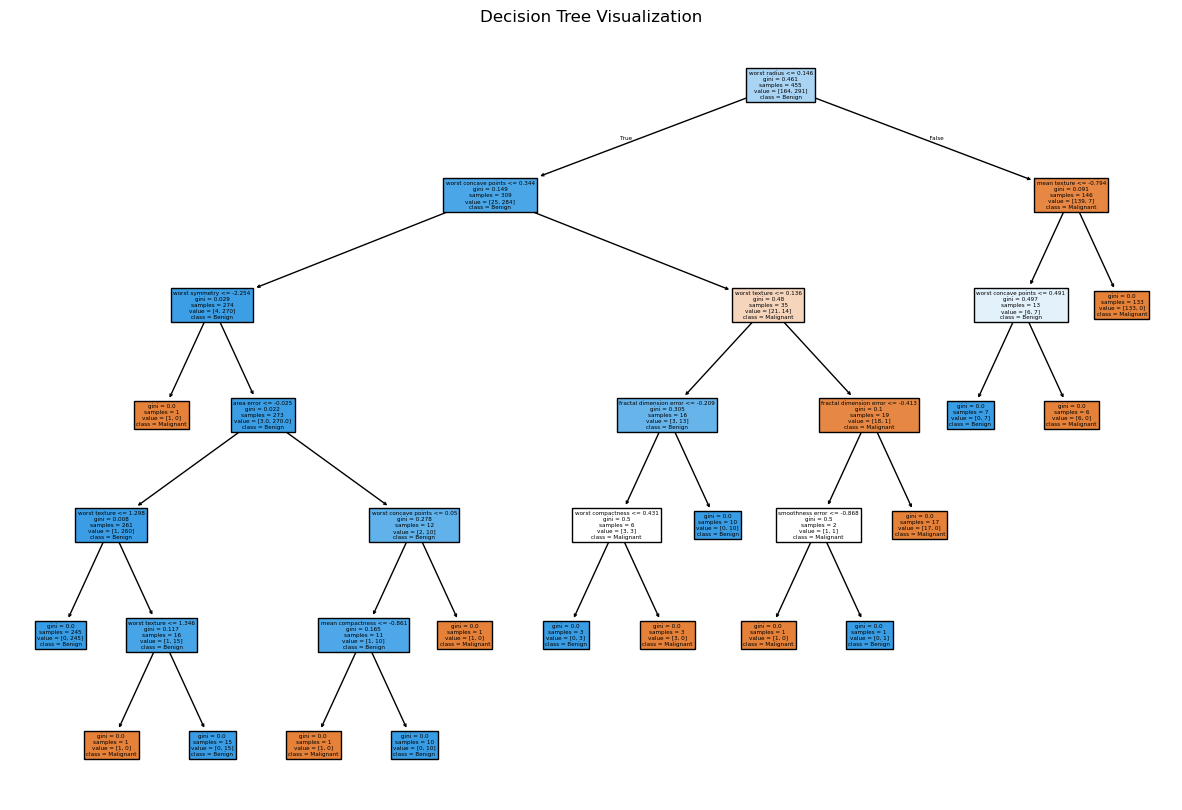

In [158]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))

plot_tree(
    dt_model,
    feature_names=data.feature_names,
    class_names=['Malignant', 'Benign'],
    filled=True
)

plt.title("Decision Tree Visualization")
plt.savefig(f"outputs/plot_{int(time.time())}.png", dpi=300, bbox_inches='tight')
plt.show()

In [159]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.9649122807017544


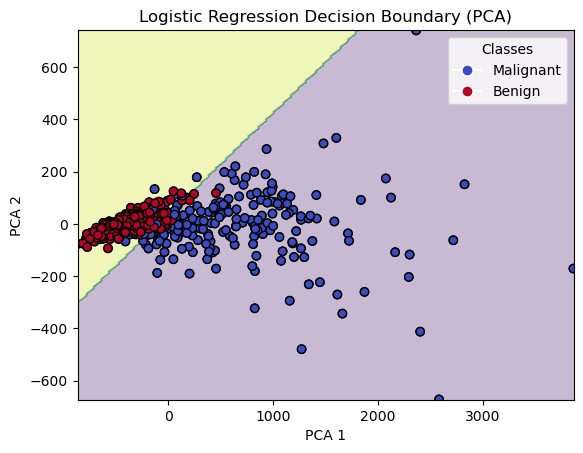

In [160]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

model = LogisticRegression()
model.fit(X_pca, y)

x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, edgecolor='k')
plt.title("Logistic Regression Decision Boundary (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', edgecolor='k')

handles = [
    plt.Line2D([0], [0], marker='o', color='w', label='Malignant',
               markerfacecolor=plt.cm.coolwarm(0.), markersize=8),
    plt.Line2D([0], [0], marker='o', color='w', label='Benign',
               markerfacecolor=plt.cm.coolwarm(1.), markersize=8)
]

plt.legend(handles=handles, title="Classes")
plt.savefig(f"outputs/plot_{int(time.time())}.png", dpi=300, bbox_inches='tight')
plt.show()

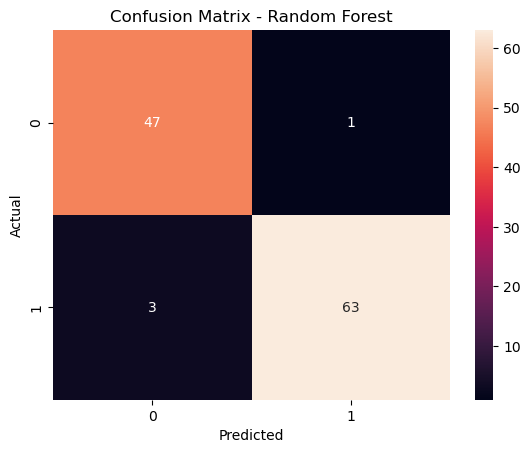

In [161]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig(f"outputs/plot_{int(time.time())}.png", dpi=300, bbox_inches='tight')
plt.show()

In [162]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm_model = SVC(kernel='linear')

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.9824561403508771


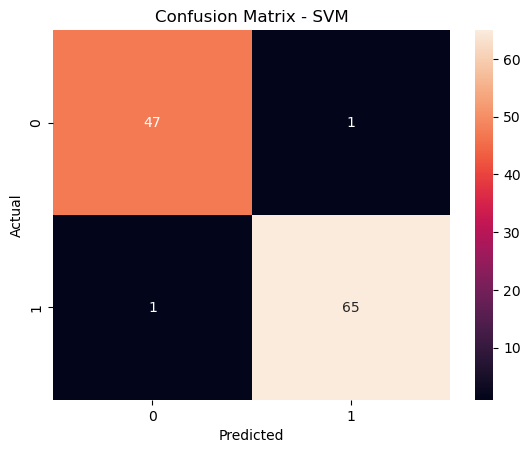

In [163]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_svm = confusion_matrix(y_test, y_pred_svm)

sns.heatmap(cm_svm, annot=True, fmt='d')
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig(f"outputs/plot_{int(time.time())}.png", dpi=300, bbox_inches='tight')
plt.show()

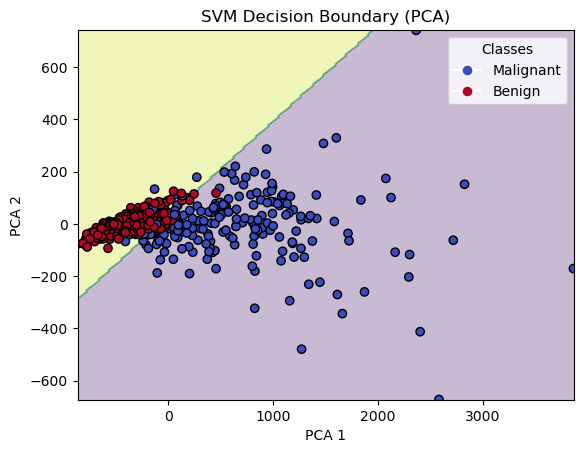

In [164]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC
import numpy as np
import matplotlib.pyplot as plt

# Reduce data to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Train SVM model
svm_model = SVC(kernel='linear')
svm_model.fit(X_pca, y)

# Create grid (safe size)
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

Z = svm_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.contourf(xx, yy, Z, alpha=0.3)

# Plot data points
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', edgecolor='k')

# Legend
handles = [
    plt.Line2D([0], [0], marker='o', color='w', label='Malignant',
               markerfacecolor=plt.cm.coolwarm(0.), markersize=8),
    plt.Line2D([0], [0], marker='o', color='w', label='Benign',
               markerfacecolor=plt.cm.coolwarm(1.), markersize=8)
]
plt.legend(handles=handles, title="Classes")

plt.title("SVM Decision Boundary (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.savefig(f"outputs/plot_{int(time.time())}.png", dpi=300, bbox_inches='tight')
plt.show()

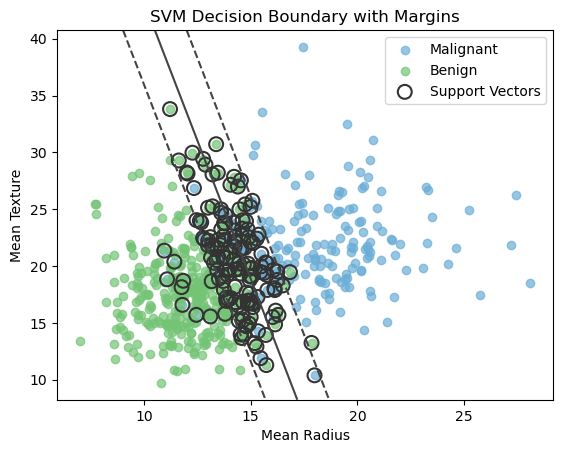

In [165]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# Select 2 features
X_plot = X.iloc[:, [0, 1]].values
y_plot = y.values

# Train SVM
svm_clf = SVC(kernel='linear', C=1)
svm_clf.fit(X_plot, y_plot)

# Separate classes for custom coloring
malignant = X_plot[y_plot == 0]
benign = X_plot[y_plot == 1]

# Plot data points with soothing colors
plt.scatter(malignant[:, 0], malignant[:, 1],
            color='#6BAED6', label='Malignant', alpha=0.7)

plt.scatter(benign[:, 0], benign[:, 1],
            color='#74C476', label='Benign', alpha=0.7)

# Get axis limits
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Create grid
xx = np.linspace(xlim[0], xlim[1], 50)
yy = np.linspace(ylim[0], ylim[1], 50)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T

# Decision function
Z = svm_clf.decision_function(xy).reshape(XX.shape)

# Plot decision boundary & margins
ax.contour(XX, YY, Z,
           colors='#444444',
           levels=[-1, 0, 1],
           linestyles=['--', '-', '--'])

# Plot support vectors
ax.scatter(svm_clf.support_vectors_[:, 0],
           svm_clf.support_vectors_[:, 1],
           s=100,
           linewidth=1.5,
           facecolors='none',
           edgecolors='#333333',
           label='Support Vectors')

# Labels & title
plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.title("SVM Decision Boundary with Margins")

# Legend
plt.legend()
plt.savefig(f"outputs/plot_{int(time.time())}.png", dpi=300, bbox_inches='tight')
plt.show()

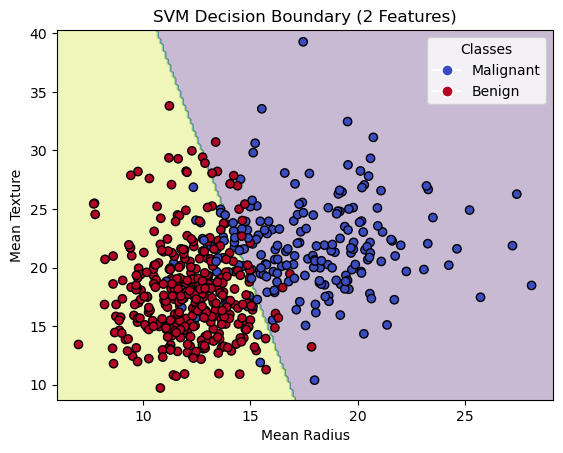

In [166]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# Select only 2 features (example: mean radius & mean texture)
X_2D = df[['mean radius', 'mean texture']].values
y_2D = df['target'].values

# Train SVM
svm_model = SVC(kernel='linear')
svm_model.fit(X_2D, y_2D)

# Create grid
x_min, x_max = X_2D[:, 0].min() - 1, X_2D[:, 0].max() + 1
y_min, y_max = X_2D[:, 1].min() - 1, X_2D[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

Z = svm_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.contourf(xx, yy, Z, alpha=0.3)

# Plot points
plt.scatter(X_2D[:, 0], X_2D[:, 1], c=y_2D, cmap='coolwarm', edgecolor='k')

# Legend
handles = [
    plt.Line2D([0], [0], marker='o', color='w', label='Malignant',
               markerfacecolor=plt.cm.coolwarm(0.), markersize=8),
    plt.Line2D([0], [0], marker='o', color='w', label='Benign',
               markerfacecolor=plt.cm.coolwarm(1.), markersize=8)
]
plt.legend(handles=handles, title="Classes")

plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.title("SVM Decision Boundary (2 Features)")
plt.savefig(f"outputs/plot_{int(time.time())}.png", dpi=300, bbox_inches='tight')
plt.show()

In [167]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.9736842105263158


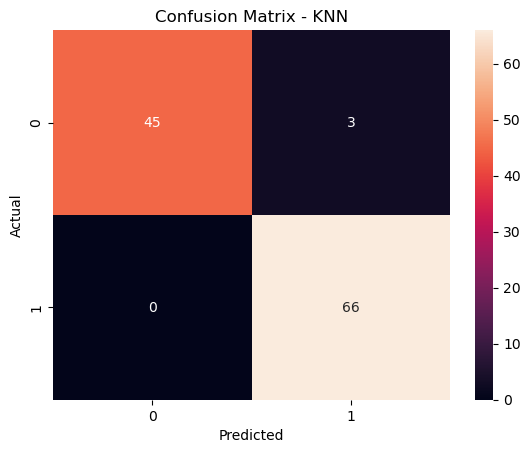

In [168]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_knn = confusion_matrix(y_test, y_pred_knn)

sns.heatmap(cm_knn, annot=True, fmt='d')
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig(f"outputs/plot_{int(time.time())}.png", dpi=300, bbox_inches='tight')
plt.show()

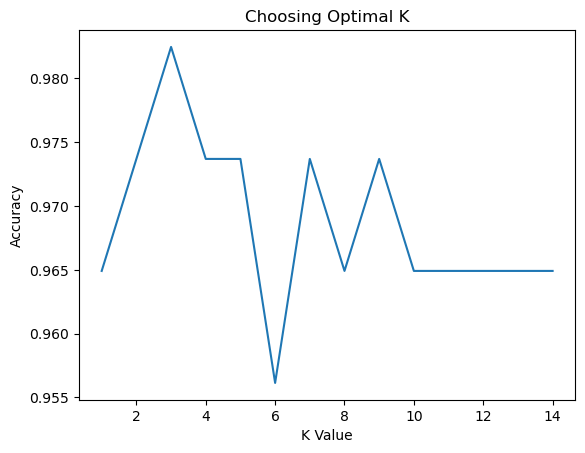

In [169]:
import matplotlib.pyplot as plt

accuracy = []

for k in range(1, 15):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy.append(accuracy_score(y_test, y_pred))

plt.plot(range(1, 15), accuracy)
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Choosing Optimal K")
plt.savefig(f"outputs/plot_{int(time.time())}.png", dpi=300, bbox_inches='tight')
plt.show()

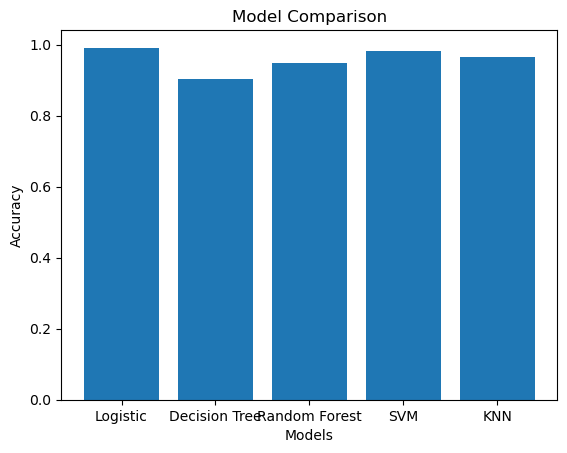

In [170]:
import matplotlib.pyplot as plt

models = ['Logistic', 'Decision Tree', 'Random Forest', 'SVM', 'KNN']
accuracies = [0.9912280701754386, 0.9035087719298246, 0.9473684210526315, 0.9824561403508771, 0.9649122807017544] 

plt.bar(models, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.savefig(f"outputs/plot_{int(time.time())}.png", dpi=300, bbox_inches='tight')
plt.show()

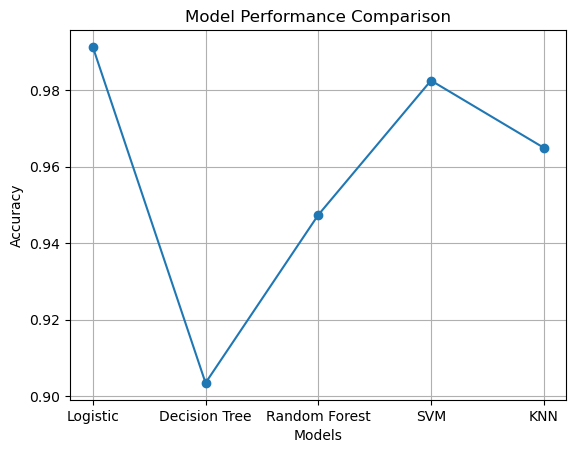

In [171]:
import matplotlib.pyplot as plt

models = ['Logistic', 'Decision Tree', 'Random Forest', 'SVM', 'KNN']
accuracies = [0.9912280701754386, 0.9035087719298246, 0.9473684210526315, 0.9824561403508771, 0.9649122807017544] 

plt.plot(models, accuracies, marker='o')
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Performance Comparison")
plt.grid()
plt.savefig(f"outputs/plot_{int(time.time())}.png", dpi=300, bbox_inches='tight')
plt.show()

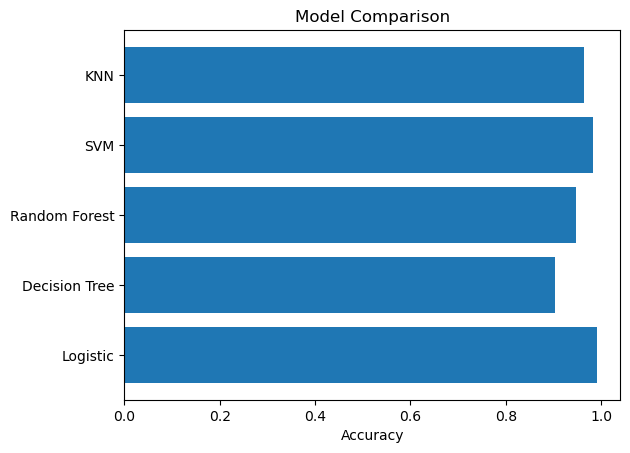

In [172]:
plt.barh(models, accuracies)
plt.xlabel("Accuracy")
plt.title("Model Comparison")
plt.savefig(f"outputs/plot_{int(time.time())}.png", dpi=300, bbox_inches='tight')
plt.show()

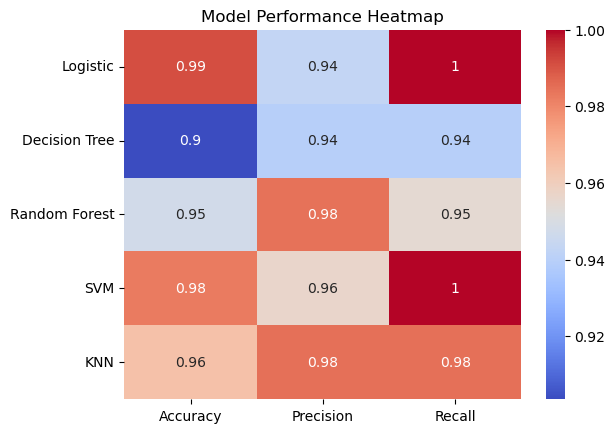

In [173]:
from sklearn.metrics import precision_score, recall_score

p1 = precision_score(y_test, y_pred)
r1 = recall_score(y_test, y_pred)

p2 = precision_score(y_test, y_pred_dt)
r2 = recall_score(y_test, y_pred_dt)

p3 = precision_score(y_test, y_pred_rf)
r3 = recall_score(y_test, y_pred_rf)

p4 = precision_score(y_test, y_pred_knn)
r4 = recall_score(y_test, y_pred_knn)

p5 = precision_score(y_test, y_pred_svm)
r5 = recall_score(y_test, y_pred_svm)
# continue for all models




import seaborn as sns
import pandas as pd

data = {
    'Accuracy': [0.9912280701754386, 0.9035087719298246, 0.9473684210526315, 0.9824561403508771, 0.9649122807017544],
    'Precision': [p1, p2, p3, p4, p5],
    'Recall': [r1, r2, r3, r4, r5]
}

df_metrics = pd.DataFrame(data, index=models)

sns.heatmap(df_metrics, annot=True, cmap='coolwarm')
plt.title("Model Performance Heatmap")
plt.savefig(f"outputs/plot_{int(time.time())}.png", dpi=300, bbox_inches='tight')
plt.show()

CLUSTERING

In the context of the Breast Cancer dataset, clustering helps in grouping tumours based on their features without using the target labels (malignant or benign). This allows us to explore hidden patterns in the data and understand whether natural groupings correspond to actual medical classifications

c:\Users\bhavy\anaconda3\envs\myenv3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\bhavy\anaconda3\envs\myenv3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\bhavy\anaconda3\envs\myenv3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\bhavy\anaconda3\envs\myenv3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning:

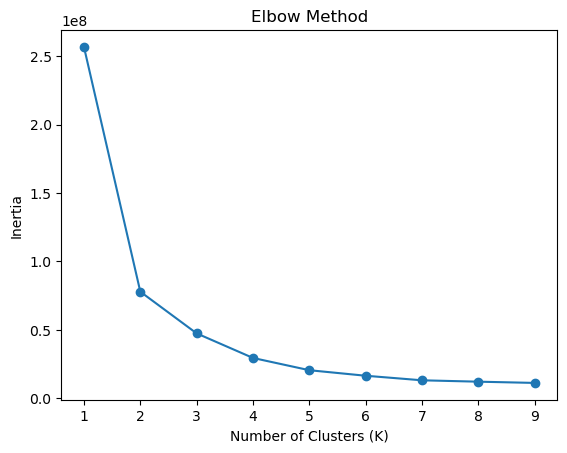

In [174]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X)
clusters = kmeans.labels_

import matplotlib.pyplot as plt

inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.savefig(f"outputs/plot_{int(time.time())}.png", dpi=300, bbox_inches='tight')
plt.show()

c:\Users\bhavy\anaconda3\envs\myenv3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


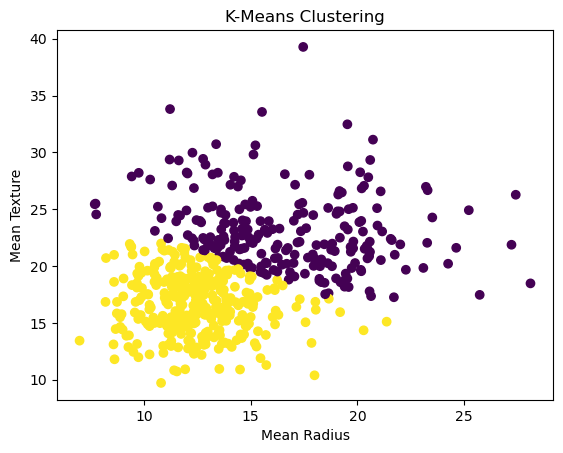

In [175]:
import matplotlib.pyplot as plt

# Use 2 features for plotting
X_2D = df[['mean radius', 'mean texture']]

kmeans = KMeans(n_clusters=2)
clusters = kmeans.fit_predict(X_2D)

plt.scatter(X_2D.iloc[:, 0], X_2D.iloc[:, 1], c=clusters, cmap='viridis')
plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.title("K-Means Clustering")
plt.savefig(f"outputs/plot_{int(time.time())}.png", dpi=300, bbox_inches='tight')
plt.show()

In [176]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.3429345460313521


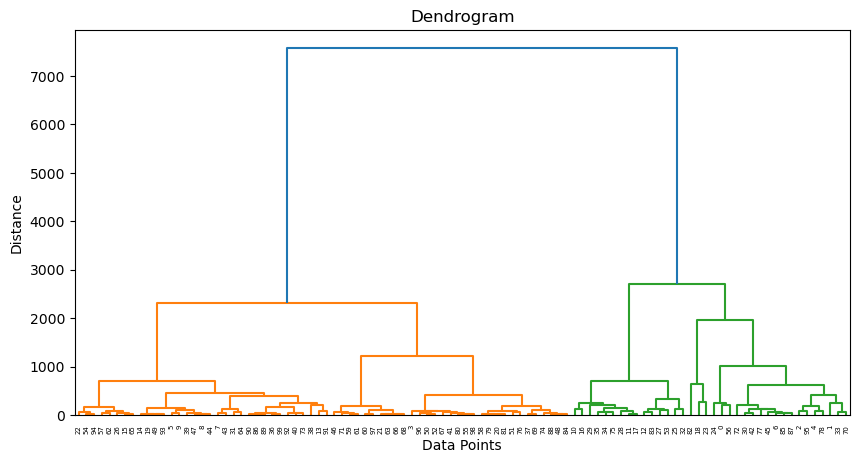

In [177]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

X_sample = X[:100]

plt.figure(figsize=(10, 5))

dendrogram = sch.dendrogram(sch.linkage(X_sample, method='ward'))

plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.savefig(f"outputs/plot_{int(time.time())}.png", dpi=300, bbox_inches='tight')
plt.show()

In [178]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=2)

clusters_hc = hc.fit_predict(X)

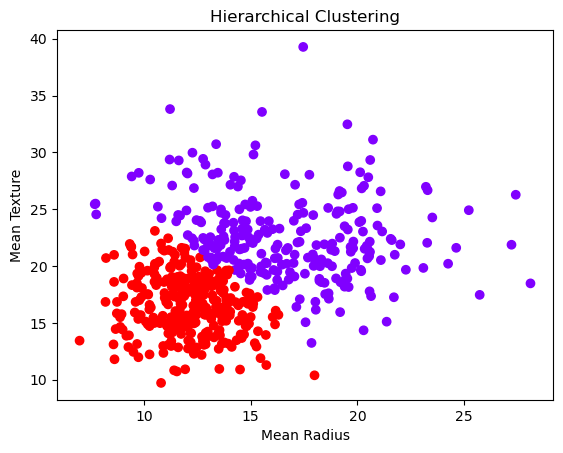

In [179]:
X_2D = df[['mean radius', 'mean texture']]

hc = AgglomerativeClustering(n_clusters=2)
clusters_hc = hc.fit_predict(X_2D)

plt.scatter(X_2D.iloc[:, 0], X_2D.iloc[:, 1], c=clusters_hc, cmap='rainbow')
plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.title("Hierarchical Clustering")
plt.savefig(f"outputs/plot_{int(time.time())}.png", dpi=300, bbox_inches='tight')
plt.show()

In [180]:
from sklearn.metrics import silhouette_score

score_hc = silhouette_score(X, clusters_hc)
print("Silhouette Score:", score_hc)

Silhouette Score: 0.36002193278868644


In [181]:
from sklearn.cluster import DBSCAN

# Apply DBSCAN (tuned parameters)
dbscan = DBSCAN(eps=2, min_samples=5)

clusters_db = dbscan.fit_predict(X)

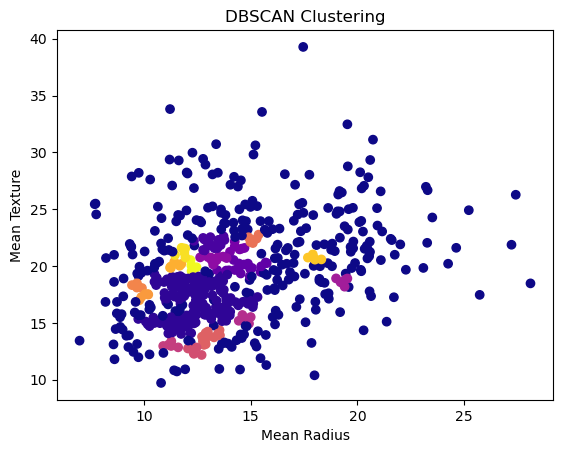

In [182]:
import matplotlib.pyplot as plt

X_2D = df[['mean radius', 'mean texture']]

dbscan = DBSCAN(eps=0.5, min_samples=5)
clusters_db = dbscan.fit_predict(X_2D)

plt.scatter(X_2D.iloc[:, 0], X_2D.iloc[:, 1], c=clusters_db, cmap='plasma')
plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.title("DBSCAN Clustering")
plt.savefig(f"outputs/plot_{int(time.time())}.png", dpi=300, bbox_inches='tight')
plt.show()

In [183]:
import numpy as np

print(np.unique(clusters_db))

[-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]


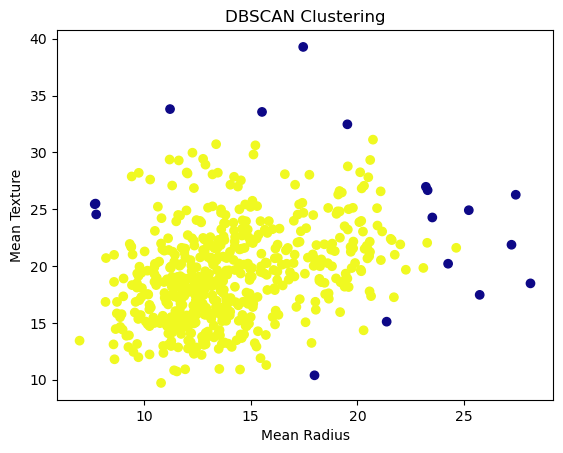

In [184]:
import matplotlib.pyplot as plt

X_2D = df[['mean radius', 'mean texture']]

dbscan = DBSCAN(eps=2, min_samples=5)
clusters_db = dbscan.fit_predict(X_2D)

plt.scatter(X_2D.iloc[:, 0], X_2D.iloc[:, 1], c=clusters_db, cmap='plasma')

plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.title("DBSCAN Clustering")
plt.savefig(f"outputs/plot_{int(time.time())}.png", dpi=300, bbox_inches='tight')
plt.show()

In [185]:
noise_points = np.sum(clusters_db == -1)
print("Number of noise points:", noise_points)

Number of noise points: 18


In [186]:
import numpy as np

noise_points = np.sum(clusters_db == -1)
print("Number of noise points:", noise_points)

Number of noise points: 18


In [187]:
from sklearn.metrics import silhouette_score

# Only compute if more than 1 cluster exists
score_db = silhouette_score(X, clusters_db)
print("Silhouette Score:", score_db)

Silhouette Score: 0.589790452047373


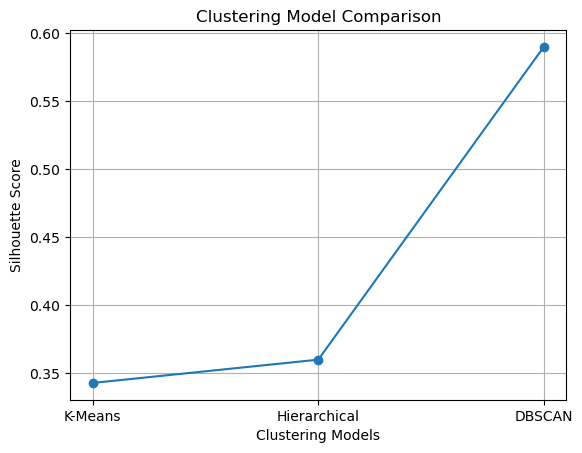

In [188]:
import matplotlib.pyplot as plt

models = ['K-Means', 'Hierarchical', 'DBSCAN']
scores = [0.34293, 0.36002, 0.58979]

plt.plot(models, scores, marker='o')
plt.xlabel("Clustering Models")
plt.ylabel("Silhouette Score")
plt.title("Clustering Model Comparison")
plt.grid()
plt.savefig(f"outputs/plot_{int(time.time())}.png", dpi=300, bbox_inches='tight')
plt.show()

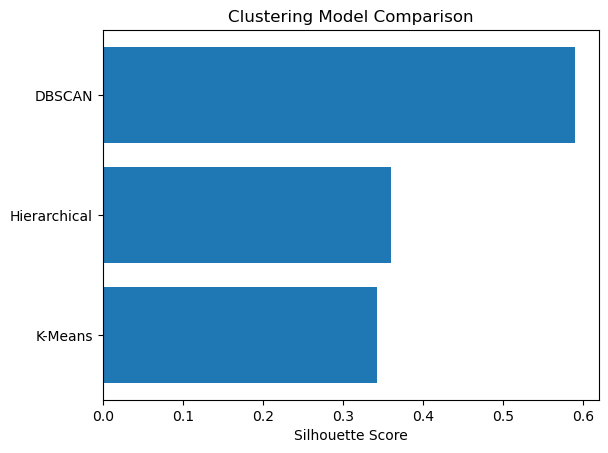

In [189]:
plt.barh(models, scores)
plt.xlabel("Silhouette Score")
plt.title("Clustering Model Comparison")
plt.savefig(f"outputs/plot_{int(time.time())}.png", dpi=300, bbox_inches='tight')
plt.show()

In [190]:
import numpy as np

noise_db = np.sum(clusters_db == -1)

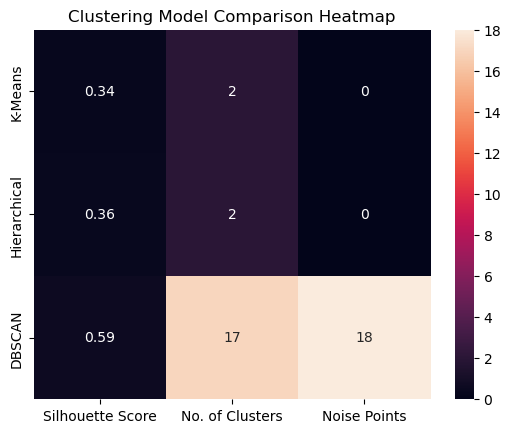

In [191]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = {
    'Silhouette Score': [0.34293, 0.36002, 0.58979],
    'No. of Clusters': [2, 2, 17],
    'Noise Points': [0, 0, noise_db]
}

models = ['K-Means', 'Hierarchical', 'DBSCAN']

df = pd.DataFrame(data, index=models)

sns.heatmap(df, annot=True)
plt.title("Clustering Model Comparison Heatmap")
plt.savefig(f"outputs/plot_{int(time.time())}.png", dpi=300, bbox_inches='tight')
plt.show()

<Axes: >

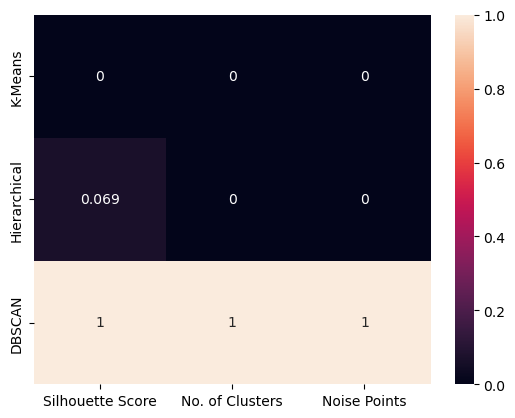

In [192]:
df_normalized = (df - df.min()) / (df.max() - df.min())
sns.heatmap(df_normalized, annot=True)

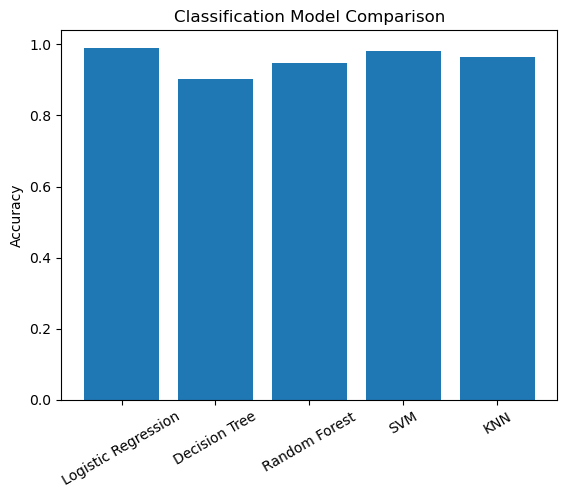

In [193]:
models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM', 'KNN']
accuracies = [0.9912280701754386, 0.9035087719298246, 0.9473684210526315, 0.9824561403508771, 0.9649122807017544]

import matplotlib.pyplot as plt

plt.bar(models, accuracies)
plt.xticks(rotation=30)
plt.ylabel("Accuracy")
plt.title("Classification Model Comparison")
plt.savefig(f"outputs/plot_{int(time.time())}.png", dpi=300, bbox_inches='tight')
plt.show()

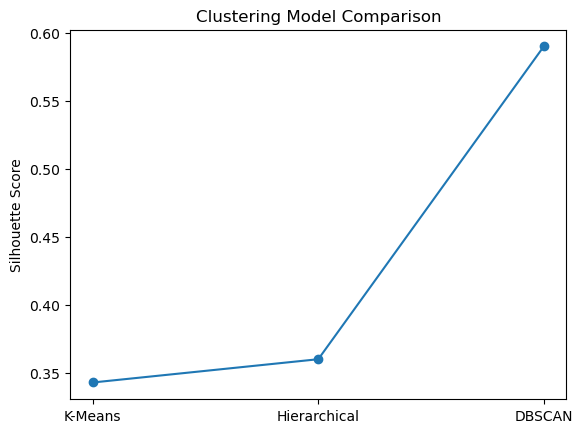

In [194]:
models = ['K-Means', 'Hierarchical', 'DBSCAN']
scores = [0.34293, 0.36002, 0.58979]

plt.plot(models, scores, marker='o')
plt.ylabel("Silhouette Score")
plt.title("Clustering Model Comparison")
plt.savefig(f"outputs/plot_{int(time.time())}.png", dpi=300, bbox_inches='tight')
plt.show()

In [195]:
print("Best Classification Model:", models[accuracies.index(max(accuracies))])
print("Best Clustering Model (by score):", models[scores.index(max(scores))])

Best Classification Model: K-Means
Best Clustering Model (by score): DBSCAN
